# Planificador vs modelos vs real (SCAN)

Corre los modelos (horizonte h=1, origen rodante) y los compara con el pronóstico del planificador y con el consumo real de SCAN.

Pasos: 1) cargar datos, 2) obtener pronósticos de los modelos, 3) emparejar con el planificador, 4) acierto, 5) gráficos y detalle por SKU.

Acierto = 1 - WAPE, con WAPE = suma|real - pronóstico| / suma real. Sesgo positivo = pronóstico por debajo del real.

In [1]:
import os, sys, json, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.cache_utils import check_alignment, check_meta, expected_meta, write_meta
from src.utils.ensemble_utils import add_ensembles
from src.utils.evaluation_utils import test_months_of
from src.utils.feature_utils import make_frame
from src.utils.member_utils import ENSEMBLE_GROUPS, collect_member_forecasts
from src.utils.panel_utils import build_panel, load_consumption
from src.utils.planner_utils import accuracy_table, compare_month, series_table
from src.utils.tuning_utils import check_tuning_window

pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

In [2]:
# Configuración
DATA = "data/consumos_long.csv"
TUNING = "results/tuning_trees.json"
PREDICTIONS = "results/member_forecasts.csv"   # caché de pronósticos de los modelos
REFIT = False        # True: vuelve a entrenar todos los modelos (tarda varios minutos)
HORIZON = 1          # meses de anticipación
N_TEST = 12          # meses de prueba (últimos 12 del dataset)
SHOW = ["planner", "ml_mean", "lgbm", "xgb", "rf", "naive", "ses"]   # columnas que se muestran
MES_DETALLE = "2026-09"                                             # mes para el detalle por SKU

## 1. Datos

In [3]:
df = load_consumption(DATA)
S = build_panel(df)
test_months = test_months_of(S, N_TEST)
print(f"{len(S.keys)} series, {len(S.plantas)} plantas, {S.labels[0]} .. {S.labels[-1]}")
print(f"meses de prueba: {S.labels[test_months[0]]} .. {S.labels[test_months[-1]]}")

2247 series, 15 plantas, 2024-01 .. 2026-09
meses de prueba: 2025-10 .. 2026-09


## 2. Modelos

Árboles (LightGBM, XGBoost, Random Forest) y modelos clásicos (naive, medias, estacional, SES, Holt amortiguado, ARIMA), cada uno pronostica el consumo mensual de cada SKU con un mes de anticipación. Los ensambles (`ml_mean` = promedio de los 3 árboles) se calculan encima.

Con `REFIT = False` se leen los pronósticos guardados, verificando que correspondan a estos datos.

In [4]:
tuned = json.loads(Path(TUNING).read_text()) if Path(TUNING).exists() else {}
check_tuning_window(tuned, S, N_TEST)          # los parámetros afinados no pueden haber visto los meses de prueba
meta = expected_meta(S, HORIZON, N_TEST, tuned)

pred_path = Path(PREDICTIONS)
if pred_path.exists() and not REFIT:
    check_meta(pred_path, meta)
    res = pd.read_csv(pred_path)
    check_alignment(res, S)
    print("pronósticos cargados de", PREDICTIONS)
else:
    res = collect_member_forecasts(S, make_frame(S, HORIZON), test_months, HORIZON, tuned, n_jobs=4)
    pred_path.parent.mkdir(parents=True, exist_ok=True)
    res.to_csv(pred_path, index=False)
    write_meta(pred_path, meta)
    print("modelos entrenados y guardados en", PREDICTIONS)

res = add_ensembles(res, ENSEMBLE_GROUPS, HORIZON)
all_models = [c[2:] for c in res.columns if c.startswith("p_")]
print(len(all_models), "modelos (incluye ensambles)")

pronósticos cargados de results/member_forecasts.csv


25 modelos (incluye ensambles)


## 3. Planificador contra real

Se leen todos los `data/planner_forecast_<mes>.csv`. El SKU del planificador no trae ancho de núcleo, así que se suman las series del dataset con mismo tipo, gramaje y ancho. Todos los modelos y el planificador se evalúan sobre exactamente los mismos SKU y el mismo mes.

In [5]:
pairs = series_table(S, df)
tables = []
for f in sorted(Path("data").glob("planner_forecast_*.csv")):
    planner = pd.read_csv(f)
    mes = planner["mes"].iloc[0]
    if mes not in S.labels:
        print(f"{mes}: no está en el consumo, se omite")
        continue
    table, missing = compare_month(planner, res, pairs, S.labels.index(mes), all_models)
    if missing:
        print(mes, "SKU del planificador sin match:", missing)
    table.insert(0, "mes", mes)
    tables.append(table)
T = pd.concat(tables, ignore_index=True)
print("meses:", sorted(T["mes"].unique()), "| filas SKU-mes:", len(T))

meses: ['2026-06', '2026-07', '2026-08', '2026-09'] | filas SKU-mes: 167


## 4. Acierto

In [6]:
# Todos los meses juntos, todos los modelos (rank 1 = mejor)
ranking = accuracy_table(T, ["planner", *all_models])
ranking["accuracy"] = (ranking["accuracy"] * 100).round(1)
ranking["wape"] = (ranking["wape"] * 100).round(1)
ranking.round(1)

,rank,model,n,mae,wape,accuracy,bias_pct
0,1,ml_econ_weighted,167,11.8,14.7,85.3,-1.1
1,2,ml_econ_mean,167,11.8,14.7,85.3,-1.3
2,3,rf,167,11.9,14.8,85.2,-1.4
3,4,ml_median,167,11.9,14.8,85.2,0.3
4,5,ml_econ_trimmed,167,11.9,14.8,85.2,-0.9
5,6,ml_weighted,167,11.9,14.8,85.2,0.3
6,7,ml_mean,167,11.9,14.8,85.2,0.3
7,7,ml_trimmed,167,11.9,14.8,85.2,0.3
8,9,econ_mean,167,12.0,14.9,85.1,-1.8
9,10,econ_weighted,167,12.0,14.9,85.1,-1.5


In [7]:
# Por mes: acierto (%) del planificador y de los modelos principales
rows = []
for mes, g in T.groupby("mes"):
    row = {"mes": mes, "n": len(g)}
    for c in SHOW:
        row[c] = round((1 - (g["real"] - g[c]).abs().sum() / g["real"].sum()) * 100, 1)
    rows.append(row)
total = {"mes": "todos", "n": len(T)}
for c in SHOW:
    total[c] = round((1 - (T["real"] - T[c]).abs().sum() / T["real"].sum()) * 100, 1)
by_month = pd.DataFrame(rows + [total]).set_index("mes")
by_month

,n,planner,ml_mean,lgbm,xgb,rf,naive,ses
mes,,,,,,,,
2026-06,45,81.1,83.8,84.1,83.5,83.7,80.8,82.2
2026-07,45,82.0,86.0,85.7,85.0,86.2,82.6,82.2
2026-08,45,88.3,84.7,84.8,82.5,85.7,79.1,85.1
2026-09,32,80.6,86.1,85.6,86.7,85.2,87.7,84.3
todos,167,83.0,85.2,85.0,84.4,85.2,82.5,83.4


In [8]:
# En cuántas filas SKU-mes quedó más cerca del real cada uno
err_model = (T["real"] - T["ml_mean"]).abs()
err_plan = (T["real"] - T["planner"]).abs()
print(f"ml_mean más cerca: {(err_model < err_plan).sum()} | planificador más cerca: {(err_plan < err_model).sum()} | empates: {(err_model == err_plan).sum()} | de {len(T)}")

ml_mean más cerca: 95 | planificador más cerca: 72 | empates: 0 | de 167


## 5. Gráficos

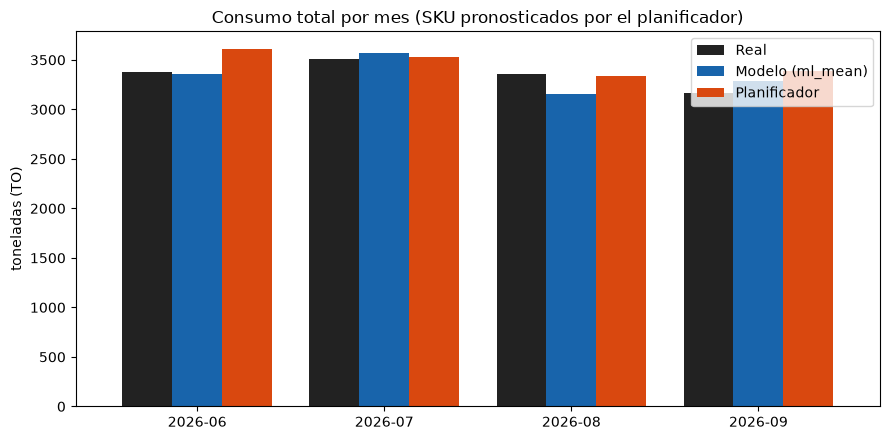

In [9]:
# Total por mes: real, modelo y planificador
tot = T.groupby("mes")[["real", "ml_mean", "planner"]].sum()
ax = tot.plot(kind="bar", figsize=(9, 4.5), color=["#222222", "#1864AB", "#D9480F"], width=0.8)
ax.set_ylabel("toneladas (TO)")
ax.set_xlabel("")
ax.set_title("Consumo total por mes (SKU pronosticados por el planificador)")
ax.legend(["Real", "Modelo (ml_mean)", "Planificador"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

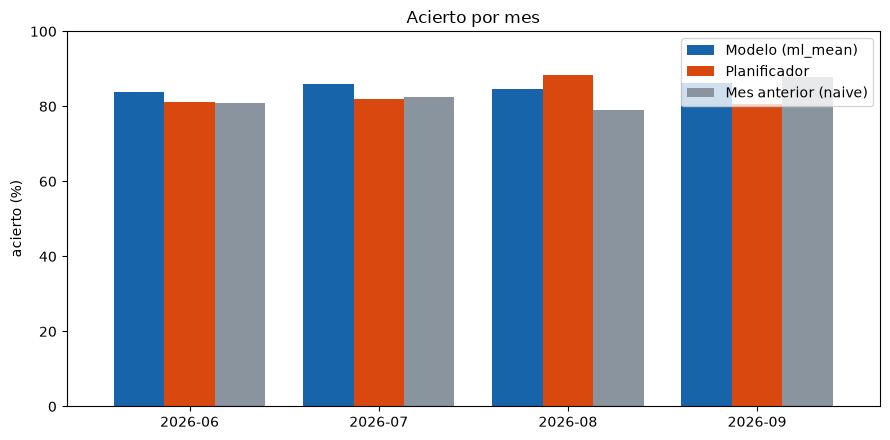

In [10]:
# Acierto por mes: modelo vs planificador vs mes anterior
ax = by_month.drop(index="todos")[["ml_mean", "planner", "naive"]].plot(kind="bar", figsize=(9, 4.5), color=["#1864AB", "#D9480F", "#8A949E"], width=0.8)
ax.set_ylabel("acierto (%)")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.set_title("Acierto por mes")
ax.legend(["Modelo (ml_mean)", "Planificador", "Mes anterior (naive)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Detalle por SKU de un mes

Cambia `MES_DETALLE` en la celda de configuración. Error % = (pronóstico - real) / real: positivo significa que pronosticó de más.

In [11]:
d = T[T["mes"] == MES_DETALLE][["sku", "real", "ml_mean", "planner"]].copy()
d["err_modelo_%"] = ((d["ml_mean"] - d["real"]) / d["real"] * 100).round(1)
d["err_planif_%"] = ((d["planner"] - d["real"]) / d["real"] * 100).round(1)
d = d.sort_values("real", ascending=False).round(1)
d.loc[len(d)] = ["TOTAL", d["real"].sum(), d["ml_mean"].sum(), d["planner"].sum(),
                 round((d["ml_mean"].sum() / d["real"].sum() - 1) * 100, 1), round((d["planner"].sum() / d["real"].sum() - 1) * 100, 1)]
d.round(1).reset_index(drop=True)

,sku,real,ml_mean,planner,err_modelo_%,err_planif_%
0,HP2/01/105gsm/2440mm,287.2,247.6,240,-13.8,-16.4
1,HP2/01/125gsm/2440mm,210.9,210.3,180,-0.3,-14.6
2,HP2/01/125gsm/2290mm,205.0,184.3,186,-10.1,-9.3
3,TSL/01/80gsm/2450mm,180.2,152.0,160,-15.7,-11.2
4,HP2/01/155gsm/2440mm,168.2,169.1,172,0.5,2.3
5,TSL/01/100gsm/2450mm,142.2,141.2,130,-0.7,-8.6
6,HP2/01/155gsm/2290mm,140.9,180.1,166,27.8,17.8
7,THP/01/125gsm/2450mm,128.8,129.8,120,0.8,-6.8
8,K/01/160gsm/2450mm,125.2,115.5,110,-7.7,-12.1
9,K/01/110gsm/2450mm,111.8,99.7,100,-10.8,-10.5


In [12]:
# Guardar la comparación completa
T.to_csv("results/planner_vs_modelos_scan.csv", index=False)
print("guardado results/planner_vs_modelos_scan.csv")

guardado results/planner_vs_modelos_scan.csv
